##  Parisagbp _Mini project2 _ Question3

# Part1

## .mat to csv

In [62]:
# https://drive.google.com/file/d/1uHuhbbbg7F4BNSjYr9oZu22KsJyCX7-e/view?usp=drive_link
# !gdown 1uHuhbbbg7F4BNSjYr9oZu22KsJyCX7-e

In [63]:
# from scipy.io import loadmat
# mat = scipy.io.loadmat('/content/97.mat')
# print(mat)

In [64]:
# print(mat.keys())

In [65]:
# import pandas as pd
# x = mat["X105_DE_time"]
# y = mat["X105_FE_time"]
# c = mat["X105_BA_time"]
# d = mat["X105RPM"]
# df = pd.DataFrame(x)
# df1 = pd.DataFrame(y)
# df2 = pd.DataFrame(c)
# df3 = pd.DataFrame(d)

# df.to_csv('example.csv', index = False)
# df1.to_csv('example1.csv', index = False)
# df2.to_csv('example2.csv', index = False)
# df3.to_csv('example3.csv', index = False)

In [66]:
# df3 = pd.DataFrame(d)
# df3.to_csv('example3.csv', index = False)

## Import Data

In [67]:
!pip install --upgrade --no-cache-dir gdown
#normal
# https://drive.google.com/file/d/18mwT7m5bDIkNIIjq3Kuohv9Xoctc2PX8/view?usp=sharing
!gdown 18mwT7m5bDIkNIIjq3Kuohv9Xoctc2PX8

#f1
# https://drive.google.com/file/d/1rzDvKLqz0GN3uimW7D5wtqytVJuKRJ2e/view?usp=sharing
!gdown 1rzDvKLqz0GN3uimW7D5wtqytVJuKRJ2e
#f2
# https://drive.google.com/file/d/1tqB2yA2bkSjKhvl3otgbpfTYN80N9PU0/view?usp=sharing
!gdown 1tqB2yA2bkSjKhvl3otgbpfTYN80N9PU0

#f3
# https://drive.google.com/file/d/1dLs7plD6W-CCrKBjorQ0JAsLq2Bbw78a/view?usp=sharing
!gdown 1dLs7plD6W-CCrKBjorQ0JAsLq2Bbw78a



ERROR: Operation cancelled by user
Downloading...
From: https://drive.google.com/uc?id=18mwT7m5bDIkNIIjq3Kuohv9Xoctc2PX8
To: /content/Normal.csv
100% 6.14M/6.14M [00:00<00:00, 53.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rzDvKLqz0GN3uimW7D5wtqytVJuKRJ2e
To: /content/Fault1.csv
100% 4.70M/4.70M [00:00<00:00, 74.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tqB2yA2bkSjKhvl3otgbpfTYN80N9PU0
To: /content/Fault2.csv
100% 4.62M/4.62M [00:00<00:00, 33.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dLs7plD6W-CCrKBjorQ0JAsLq2Bbw78a
To: /content/Fault3.csv
100% 4.61M/4.61M [00:00<00:00, 176MB/s]


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [69]:
Normal = pd.read_csv('/content/Normal.csv')

Normal=Normal.X097_DE_time
null1 = Normal.isnull().sum()
print(null1)

Fault1 = pd.read_csv('/content/Fault1.csv')
Fault1=Fault1.X105_DE_time
null2 = Fault1.isnull().sum()
print(null2)

Fault2 = pd.read_csv('/content/Fault2.csv')
Fault2=Fault2.X118_DE_time
null3 = Fault2.isnull().sum()
print(null3)

Fault3 = pd.read_csv('/content/Fault3.csv')
Fault3=Fault3.X130_DE_time
null4 = Fault3.isnull().sum()
print(null4)

0
0
0
0


## Data

In [70]:
Normal_data = Normal
Fault_1 = Fault1
Fault_2 = Fault2
Fault_3 = Fault3
# Extract 100 samples with length of 200
sample_length = 200
num_samples = 100
Normal_samples = []
Fault1_samples = []
Fault2_samples = []
Fault3_samples = []
# Extract samples from class Normal
for i in range(num_samples):
    # np.random.seed(64)
    start_idx = np.random.randint(0, len(Normal_data) - sample_length + 1)
    sample = Normal_data[start_idx:start_idx + sample_length]
    Normal_samples.append(sample)
# Extract samples from class Fault1
for i in range(num_samples):
    # np.random.seed(64)
    start_idx = np.random.randint(0, len(Fault_1) - sample_length + 1)
    sample = Fault_1[start_idx:start_idx + sample_length]
    Fault1_samples.append(sample)
# Extract samples from class Fault2
for i in range(num_samples):
    # np.random.seed(64)
    start_idx = np.random.randint(0, len(Fault_2) - sample_length + 1)
    sample = Fault_2[start_idx:start_idx + sample_length]
    Fault2_samples.append(sample)
    # Extract samples from class Fault3
for i in range(num_samples):
    # np.random.seed(64)
    start_idx = np.random.randint(0, len(Fault_3) - sample_length + 1)
    sample = Fault_3[start_idx:start_idx + sample_length]
    Fault3_samples.append(sample)
# Convert lists of samples to numpy arrays
Normal_samples = np.array(Normal_samples)
Fault1_samples = np.array(Fault1_samples)
Fault2_samples = np.array(Fault2_samples)
Fault3_samples = np.array(Fault3_samples)
# Create labels for the samples
Normal_labels = np.zeros((num_samples, 1))
Fault1_labels = np.ones((num_samples, 1))
Fault2_labels= np.full((num_samples, 1), 2)
Fault3_labels= np.full((num_samples, 1), 3)
# Concatenate the data and labels for both classes
data_matrix = np.vstack((Normal_samples, Fault1_samples, Fault2_samples, Fault3_samples))
print("Data Matrix shape:")
print(data_matrix.shape)
labels = np.vstack((Normal_labels, Fault1_labels, Fault2_labels, Fault3_labels))
print("labels Matrix:")
#print(labels.shape)
main_matrix = np.hstack((data_matrix, labels))
print("data & label matrix:")
print(main_matrix)

Data Matrix shape:
(400, 200)
labels Matrix:
data & label matrix:
[[-1.55835692e-01 -1.84833231e-01 -1.59590769e-01 ... -7.46843080e-02
  -6.13329230e-02  0.00000000e+00]
 [ 1.22665846e-01  1.65849231e-01  1.62928615e-01 ...  6.46707690e-02
   8.44892310e-02  0.00000000e+00]
 [ 3.29612310e-02  7.69790770e-02  1.13486769e-01 ...  4.94418460e-02
   8.11513850e-02  0.00000000e+00]
 ...
 [-7.43140720e-02  2.19693513e-01 -4.34513970e-02 ...  2.07104790e-02
  -5.19792420e-02  3.00000000e+00]
 [-1.55125549e-01  1.70150798e-01  6.29842216e-01 ...  2.98474551e-01
  -1.21826347e-01  3.00000000e+00]
 [-1.38882036e-01 -4.18270460e-02  4.06088000e-04 ...  4.79183630e-02
   1.09643710e-02  3.00000000e+00]]


## Feature extraction

In [79]:
mean_values = np.mean(data_matrix, axis=1)
std_dev_values = np.std(data_matrix, axis=1)
peak_values = np.max(np.abs(data_matrix), axis=1)
rms_value = np.sqrt(np.mean(data_matrix**2, axis=1))
crest_factor = peak_values / rms_value
peak_to_peak_value=np.max(data_matrix, axis=1)-np.min(data_matrix, axis=1)
Abs_Mean_value=np.mean(np.abs(data_matrix), axis=1)
Impulse_Factor=peak_values/Abs_Mean_value
# Concatenate mean and standard deviation as features
features = np.column_stack((mean_values, std_dev_values, peak_values, rms_value, crest_factor, peak_to_peak_value, Abs_Mean_value, Impulse_Factor))
# Create DataFrame
Data = pd.DataFrame(features, columns=['Mean', 'Standard Deviation','Peak', 'RMS', 'Crest Factor', 'Peak to Peak', 'Absolute Mean', 'Impulse Factor'])
print(Data)

         Mean  Standard Deviation      Peak       RMS  Crest Factor  \
0    0.016739            0.086732  0.202148  0.088333      2.288487   
1    0.010304            0.079380  0.198810  0.080046      2.483696   
2    0.019365            0.074309  0.172525  0.076790      2.246700   
3    0.019807            0.085459  0.243871  0.087725      2.779963   
4    0.010101            0.062621  0.155627  0.063431      2.453489   
..        ...                 ...       ...       ...           ...   
395  0.007799            0.456016  1.629224  0.456082      3.572216   
396  0.021080            0.774833  3.131749  0.775120      4.040340   
397  0.015385            0.602625  2.891751  0.602822      4.797026   
398  0.019689            0.627346  2.375208  0.627655      3.784258   
399  0.028002            0.731271  2.566069  0.731807      3.506484   

     Peak to Peak  Absolute Mean  Impulse Factor  
0        0.386982       0.075379        2.681759  
1        0.364660       0.066012        3.011

## Shuffle

In [72]:
# shuffle
from sklearn.utils import shuffle
Data = shuffle(Data, random_state=64)

## Label

In [80]:
Labeled_Data=np.hstack((Data, labels))
np.random.seed(64)
np.random.shuffle(Labeled_Data)
print(Labeled_Data)
# Remove the header from the variables
data = Data.values
label = labels
# Split the data into train/validation/test sets
train_data, test_data, train_label, test_label = train_test_split(data, label, test_size=0.15, random_state=64)
train_data, val_data, train_label, val_label = train_test_split(train_data, train_label, test_size=0.15, random_state=64)
# Print shape of each set
print(f"train_data shape: {train_data.shape}")
print(f"val_data shape: {val_data.shape}")
print(f"test_data shape: {test_data.shape}")
print(f"train_label shape: {train_label.shape}")
print(f"val_label shape: {val_label.shape}")
print(f"test_label shape: {test_label.shape}")

[[0.01770543 0.79716726 2.64688044 ... 0.49213783 5.37833155 3.        ]
 [0.02358084 0.06534583 0.17231631 ... 0.05725345 3.00971051 0.        ]
 [0.01380211 0.2726631  0.95365665 ... 0.20289772 4.70018413 1.        ]
 ...
 [0.02144253 0.07461448 0.17461108 ... 0.06411064 2.7235898  0.        ]
 [0.01383298 0.29587709 1.03763561 ... 0.20776428 4.99429268 1.        ]
 [0.0149221  0.25897072 0.90086523 ... 0.19180259 4.69683561 1.        ]]
train_data shape: (289, 8)
val_data shape: (51, 8)
test_data shape: (60, 8)
train_label shape: (289, 1)
val_label shape: (51, 1)
test_label shape: (60, 1)


## MinMaxScaler

In [81]:
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data)
test_data = scaler.transform(test_data)

# Part2

In [82]:
from keras.utils import to_categorical
x_train = train_data
y_train = train_label.ravel()
x_test = test_data
y_test = test_label.ravel()
y_train = to_categorical(y_train, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)
print(x_train.shape, y_train.shape)

(289, 8) (289, 4)


## MLP with 2 hidden layer using keras

In [100]:
import tensorflow as tf
from tensorflow import keras
from keras import preprocessing
from keras.models import Sequential
from keras.layers import Dense
keras.utils.set_random_seed(64)
np.random_state=64
np.random.seed(64)

model = Sequential()
# Add the first hidden layer with 8 neurons and relu activation function
model.add(Dense(9, activation='relu', input_shape=(x_train.shape[1],)))
# Add the second hidden layer with 4 neurons and relu activation function
model.add(Dense(5, activation='relu'))
# Add an output layer with 4 neuron and softmax activation function
model.add(Dense(4, activation='softmax'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 9)                 81        
                                                                 
 dense_16 (Dense)            (None, 5)                 50        
                                                                 
 dense_17 (Dense)            (None, 4)                 24        
                                                                 
Total params: 155 (620.00 Byte)
Trainable params: 155 (620.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [84]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
keras.utils.set_random_seed(64)
initial_lr = 0.05
optimizer = Adam(learning_rate=initial_lr)
model.compile(optimizer=optimizer,
              loss='BinaryCrossentropy',
              metrics=['accuracy'])
np.random_state=64
np.random.seed(64)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.001)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(x_train, y_train, validation_split=0.1, epochs=100, batch_size=50,
                      callbacks=[reduce_lr, early_stop, checkpoint])

Epoch 1/100
6/6 [==============================] - 1s 104ms/step - loss: 0.6181 - accuracy: 0.2846 - val_loss: 0.5552 - val_accuracy: 0.2414 - lr: 0.0500
Epoch 2/100
1/6 [====>.........................] - ETA: 0s - loss: 0.5412 - accuracy: 0.2400

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - 0s 28ms/step - loss: 0.4995 - accuracy: 0.2500 - val_loss: 0.4507 - val_accuracy: 0.2414 - lr: 0.0500
Epoch 3/100
6/6 [==============================] - 0s 42ms/step - loss: 0.4164 - accuracy: 0.5038 - val_loss: 0.3885 - val_accuracy: 0.6207 - lr: 0.0500
Epoch 4/100
6/6 [==============================] - 0s 33ms/step - loss: 0.3578 - accuracy: 0.8077 - val_loss: 0.3405 - val_accuracy: 1.0000 - lr: 0.0500
Epoch 5/100
6/6 [==============================] - 0s 36ms/step - loss: 0.3173 - accuracy: 0.9577 - val_loss: 0.3213 - val_accuracy: 0.8276 - lr: 0.0500
Epoch 6/100
6/6 [==============================] - 0s 58ms/step - loss: 0.2898 - accuracy: 0.8385 - val_loss: 0.2964 - val_accuracy: 0.7931 - lr: 0.0500
Epoch 7/100
6/6 [==============================] - 0s 27ms/step - loss: 0.2511 - accuracy: 0.9500 - val_loss: 0.2685 - val_accuracy: 0.9655 - lr: 0.0500
Epoch 8/100
6/6 [==============================] - 0s 26ms/step - loss: 0.2173 - accuracy: 0.9

In [85]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Model accuracy on test data: {accuracy:.4f}")

Model accuracy on test data: 0.9833


In [86]:
#Evaluate the model
loss = model.evaluate(x_test , y_test)

2/2 [==============================] - 0s 10ms/step - loss: 0.0411 - accuracy: 0.9833


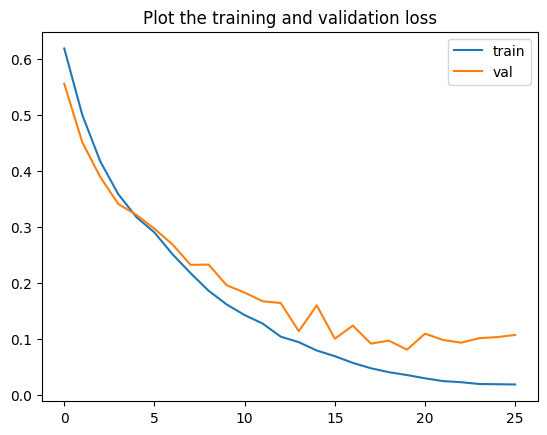

In [99]:
# Plot the training and validation loss
plt.plot(history.history['loss'], label='train')   # Training loss
plt.plot(history.history['val_loss'], label='val')  # Validation loss
plt.title("Plot the training and validation loss")
plt.legend()
plt.show()

## MLP with 2 hidden layer using Sklearn

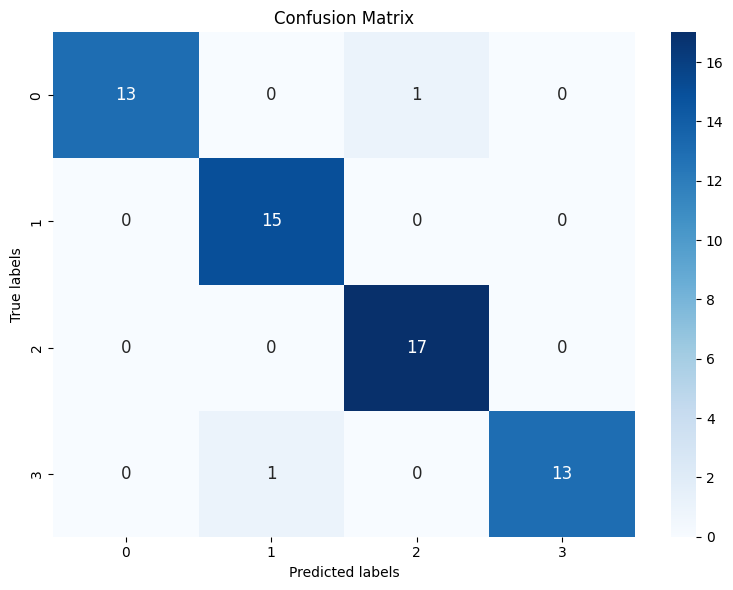

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96        14
         1.0       0.94      1.00      0.97        15
         2.0       0.94      1.00      0.97        17
         3.0       1.00      0.93      0.96        14

    accuracy                           0.97        60
   macro avg       0.97      0.96      0.97        60
weighted avg       0.97      0.97      0.97        60



In [98]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

x_train = train_data
y_train = train_label.ravel()
x_test = test_data
y_test = test_label.ravel()
# Assuming you've trained your model already
model = MLPClassifier(hidden_layer_sizes=(9, 5), activation='relu', solver='adam',
                      batch_size=50, learning_rate_init=0.05,
                       max_iter=100, random_state=64,
                      early_stopping=True, validation_fraction=0.1)
model.fit(x_train, y_train)

# Making predictions on the test set
y_pred = model.predict(x_test)

# Calculating confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix as a heatmap with fitted text
plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 12})

# Get the axis to modify layout
plt.gca().set_ylim(len(np.unique(y_test)), 0)  # Fix for matplotlib 3.1.1 and 3.1.2
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

plt.tight_layout()
plt.show()

# Printing classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

#Part4

## Cross Validation

A solution to over-fitting problem is a procedure called cross-validation (CV).

## DecisionTreeClassifier

In [105]:
import pandas as pd
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [102]:
!gdown 1JWWUiJ5rtdrnGEdfAcZSLBuTLxxvUIj6
data = pd.read_csv('drug200.csv')
data

Downloading...
From: https://drive.google.com/uc?id=1JWWUiJ5rtdrnGEdfAcZSLBuTLxxvUIj6
To: /content/drug200.csv
100% 5.83k/5.83k [00:00<00:00, 8.66MB/s]


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
data = pd.read_csv('drug200.csv')
#sex
sex = data['Sex']
#replacing labels
for i in range(200):
  if sex[i] == 'M':
     sex[i]= 0
  else:
     sex[i] = 1

data['Sex'] = sex

#BP
bp = data['BP']
#replacing labels
for i in range(200):
  if bp[i] == 'LOW':
     bp[i]= 0
  elif bp[i] == 'NORMAL':
     bp[i] = 1
  else:
     bp[i] = 2
data['BP'] = bp

#CH
ch = data['Cholesterol']

for i in range(200):
  if ch[i] == 'NORMAL':
     ch[i]= 0
  else:
     ch[i] = 1

data['Cholesterol'] = ch




In [111]:
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,2,1,25.355,drugY
1,47,0,0,1,13.093,drugC
2,47,0,0,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,0,1,18.043,drugY
...,...,...,...,...,...,...
195,56,1,0,1,11.567,drugC
196,16,0,0,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


In [104]:
from sklearn.model_selection import train_test_split

X = data.drop('Drug', axis=1)
y = data['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=64)

In [108]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.9833333333333333

### K-Fold Cross Validation



In [112]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kf = KFold(n_splits=10)
scores = cross_val_score(model, X, y, cv=kf)
print(scores)
print("mean Scores:", scores.mean())
print("std Scores:", scores.std())

[1.   1.   1.   1.   1.   1.   0.9  0.95 1.   1.  ]
mean Scores: 0.985
std Scores: 0.032015621187164243
